# 01 — Exploration
**Goal:** Team-level summary stats for the Seattle Mariners, 2015–present. First end-to-end run of the pipeline.

Deliverable for Week 1-2. Answers: *How have the Mariners performed relative to payroll over the past decade?*

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.ingest.pull_data import get_db, pull_team_batting

sns.set_theme(style='whitegrid')
MARINERS_COLORS = {'primary': '#005C5C', 'secondary': '#0C2C56', 'accent': '#C4CED4'}

## 1. Initialize DB & pull team batting

In [2]:
con = get_db()
print("Tables:", con.execute("SHOW TABLES").fetchdf())

Tables:                name
0         contracts
1       draft_picks
2    player_seasons
3           players
4  statcast_quality
5      team_seasons


In [3]:
team_batting = pull_team_batting(start=2015)
team_batting.head()

,Season,Team,G,AB,PA,H,1B,2B,3B,HR,...,GDP,SB,CS,WAR,wOBA,wRC+,AVG,OBP,SLG,OPS
0,2015,Diamondbacks,1801.0,4822.0,5355.0,1284.0,881.0,244.0,43.0,116.0,...,111.0,129.0,43.0,19.201942,0.315715,93.340276,0.266280,0.324675,0.406885,0.731560
1,2015,Braves,1425.0,4155.0,4602.0,1067.0,782.0,202.0,15.0,68.0,...,111.0,55.0,28.0,10.256908,0.294906,84.537852,0.256799,0.315801,0.361733,0.677534
2,2015,Orioles,1593.0,4893.0,5363.0,1239.0,799.0,217.0,17.0,206.0,...,121.0,36.0,22.0,19.189576,0.320345,101.026588,0.253219,0.310571,0.430820,0.741390
3,2015,Red Sox,1575.0,4984.0,5490.0,1346.0,913.0,263.0,27.0,143.0,...,109.0,60.0,25.0,17.179943,0.323378,100.750354,0.270064,0.326927,0.419743,0.746670
4,2015,Cubs,1948.0,5284.0,5970.0,1301.0,846.0,259.0,30.0,166.0,...,99.0,89.0,36.0,25.732120,0.314716,97.135165,0.246215,0.323624,0.400833,0.724456


## 2. Filter to Mariners

In [4]:
sea = team_batting[team_batting['Team'] == 'Mariners'].sort_values('Season')
sea[['Season', 'G', 'PA', 'HR', 'wOBA', 'wRC+', 'WAR']].round(3)

,Season,G,PA,HR,wOBA,wRC+,WAR
23,2015,1517.0,5002.0,169.0,0.315,102.192,16.302
53,2016,1808.0,6079.0,220.0,0.327,109.285,24.175
83,2017,1699.0,5789.0,190.0,0.324,105.049,23.048
113,2018,1682.0,5609.0,166.0,0.313,99.977,18.100
143,2019,1654.0,5544.0,199.0,0.313,98.274,14.758
173,2020,489.0,1801.0,50.0,0.292,87.942,3.364
203,2021,1579.0,5485.0,191.0,0.302,94.805,10.964
233,2022,1546.0,5679.0,180.0,0.312,109.443,24.290
263,2023,1470.0,5564.0,194.0,0.327,113.898,27.442
293,2024,1446.0,4993.0,163.0,0.298,100.600,17.137


## 3. WAR trend over time

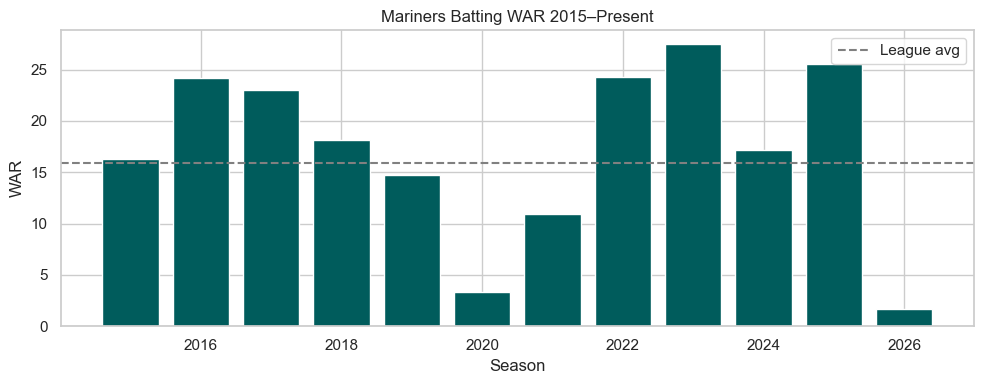

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sea['Season'], sea['WAR'], color=MARINERS_COLORS['primary'])
ax.axhline(team_batting.groupby('Season')['WAR'].mean().mean(), 
           linestyle='--', color='gray', label='League avg')
ax.set(title='Mariners Batting WAR 2015–Present', xlabel='Season', ylabel='WAR')
ax.legend()
plt.tight_layout()
plt.show()

## 4. League-wide wRC+ context (all teams)

In [6]:
# Rank Mariners wRC+ vs all teams each season
team_batting['wrc_rank'] = team_batting.groupby('Season')['wRC+'].rank(ascending=False)
sea_ranks = team_batting[team_batting['Team'] == 'Mariners'][['Season', 'wRC+', 'wrc_rank']]
sea_ranks

,Season,wRC+,wrc_rank
23,2015,102.192056,7.0
53,2016,109.285350,2.0
83,2017,105.048559,5.0
113,2018,99.976889,11.0
143,2019,98.274195,13.0
173,2020,87.941679,27.0
203,2021,94.804891,18.0
233,2022,109.443417,8.0
263,2023,113.898423,5.0
293,2024,100.600174,17.0


In [7]:
print(team_batting['Team'].unique())

['Diamondbacks' 'Braves' 'Orioles' 'Red Sox' 'Cubs' 'White Sox' 'Reds'
 'Guardians' 'Rockies' 'Tigers' 'Astros' 'Royals' 'Angels' 'Dodgers'
 'Marlins' 'Brewers' 'Twins' 'Mets' 'Yankees' 'Athletics' 'Phillies'
 'Pirates' 'Padres' 'Mariners' 'Giants' 'Cardinals' 'Rays' 'Rangers'
 'Blue Jays' 'Nationals']


## 5. Mariners player-level batting

In [8]:
from src.ingest.pull_data import pull_batting
from src.transform.clean import normalize_batting

batting_raw = pull_batting(start=2015)
batting = normalize_batting(batting_raw)

sea_players = batting[batting['is_mariners']].sort_values(['season', 'war'], ascending=[True, False])
print(f"{len(batting):,} player-seasons total  |  {len(sea_players):,} Mariners player-seasons")
sea_players[['season', 'name_full', 'pa', 'hr', 'woba', 'wrc_plus', 'war']].head(15)

8,716 player-seasons total  |  262 Mariners player-seasons


,season,name_full,pa,hr,woba,wrc_plus,war
20,2015,Nelson Cruz,655.0,44.0,0.395990,157.953875,5.032418
47,2015,Kyle Seager,686.0,26.0,0.334505,115.498474,3.769490
82,2015,Robinson Cano,674.0,21.0,0.335238,116.004469,2.772498
104,2015,Franklin Gutierrez,189.0,15.0,0.409689,167.413302,2.281873
129,2015,Seth Smith,452.0,12.0,0.331424,113.371117,1.838228
134,2015,Ketel Marte,247.0,2.0,0.330043,112.417239,1.781858
176,2015,Brad Miller,497.0,11.0,0.319256,104.968917,1.313458
224,2015,Mike Zunino,386.0,11.0,0.235195,46.923887,0.728202
269,2015,Shawn O'Malley,57.0,1.0,0.354384,129.224538,0.404629
354,2015,Jesus Sucre,142.0,1.0,0.189283,15.221558,0.130998


In [ ]:
from src.transform.load import load_players, load_player_seasons

sea_batting = batting[batting['is_mariners']].copy()
new_players = load_players(con, sea_batting)
new_seasons = load_player_seasons(con, sea_batting)
print(f"Inserted {new_players} new players, {new_seasons} player-seasons")
print(f"players table:        {con.execute('SELECT COUNT(*) FROM players').fetchone()[0]} rows")
print(f"player_seasons table: {con.execute('SELECT COUNT(*) FROM player_seasons').fetchone()[0]} rows")

In [9]:
# Top 3 Mariners batters by WAR each season
top3 = (
    sea_players
    .sort_values(['season', 'war'], ascending=[True, False])
    .groupby('season', group_keys=False)
    .head(3)
    [['season', 'name_full', 'pa', 'hr', 'woba', 'wrc_plus', 'war']]
    .round(3)
    .reset_index(drop=True)
)
top3

,season,name_full,pa,hr,woba,wrc_plus,war
0,2015,Nelson Cruz,655.0,44.0,0.396,157.954,5.032
1,2015,Kyle Seager,686.0,26.0,0.335,115.498,3.769
2,2015,Robinson Cano,674.0,21.0,0.335,116.004,2.772
3,2016,Robinson Cano,715.0,39.0,0.370,138.722,6.392
4,2016,Kyle Seager,676.0,30.0,0.363,133.633,5.947
5,2016,Nelson Cruz,667.0,43.0,0.383,147.694,4.675
6,2017,Mike Zunino,435.0,25.0,0.355,125.775,4.419
7,2017,Kyle Seager,650.0,27.0,0.326,106.443,3.552
8,2017,Jean Segura,566.0,11.0,0.334,111.465,3.543
9,2018,Mitch Haniger,683.0,26.0,0.367,136.771,4.983


## 6. Payroll → team_seasons

Opening-day payroll figures from [Spotrac](https://www.spotrac.com/mlb/seattle-mariners/payroll/).  
Values below are approximate — verify and update against the exact Spotrac totals before running Pillar 1.

In [10]:
# Approximate opening-day payrolls ($M) — verify exact figures from Spotrac before Pillar 1
payroll_seed = pd.DataFrame([
    {"season": 2015, "payroll_m": 120.0},
    {"season": 2016, "payroll_m": 131.0},
    {"season": 2017, "payroll_m": 165.0},
    {"season": 2018, "payroll_m": 161.0},
    {"season": 2019, "payroll_m": 145.0},
    {"season": 2020, "payroll_m":  55.0},
    {"season": 2021, "payroll_m":  80.0},
    {"season": 2022, "payroll_m": 115.0},
    {"season": 2023, "payroll_m": 140.0},
    {"season": 2024, "payroll_m": 103.0},
    {"season": 2025, "payroll_m": 130.0},
])
payroll_seed["team"] = "Mariners"

# Upsert into team_seasons
con.register("_payroll", payroll_seed)
con.execute("DELETE FROM team_seasons WHERE team = 'Mariners'")
con.execute("""
    INSERT INTO team_seasons (id, team, season, payroll_m)
    SELECT
        COALESCE((SELECT MAX(id) FROM team_seasons), 0) + row_number() OVER () AS id,
        team, season, payroll_m
    FROM _payroll
""")

con.execute("SELECT season, team, payroll_m FROM team_seasons ORDER BY season").fetchdf()

,season,team,payroll_m
0,2015,Mariners,120.0
1,2016,Mariners,131.0
2,2017,Mariners,165.0
3,2018,Mariners,161.0
4,2019,Mariners,145.0
5,2020,Mariners,55.0
6,2021,Mariners,80.0
7,2022,Mariners,115.0
8,2023,Mariners,140.0
9,2024,Mariners,103.0


In [ ]:
# ETL complete — release the write lock so other notebooks can access the DB
con.close()
con = get_db(read_only=True)
print("Write connection closed; reopened read-only for analysis.")

## 7. Payroll vs WAR — Pillar 1 preview

The "hero chart" for the case study: does spending correlate with batting production? Each point is one Mariners season.

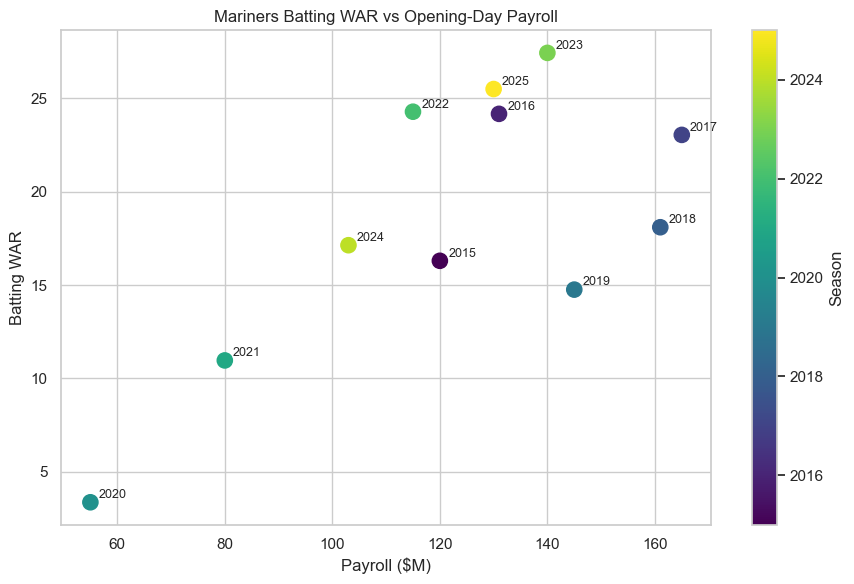


WAR per $M spent (efficiency ranking):
 Season  payroll_m    WAR  war_per_m
   2022      115.0 24.290      0.211
   2025      130.0 25.506      0.196
   2023      140.0 27.442      0.196
   2016      131.0 24.175      0.185
   2024      103.0 17.137      0.166
   2017      165.0 23.048      0.140
   2021       80.0 10.964      0.137
   2015      120.0 16.302      0.136
   2018      161.0 18.100      0.112
   2019      145.0 14.758      0.102
   2020       55.0  3.364      0.061


In [11]:
pillar1 = (
    sea[['Season', 'WAR']]
    .merge(payroll_seed.rename(columns={'season': 'Season'}), on='Season')
)
pillar1['war_per_m'] = pillar1['WAR'] / pillar1['payroll_m']

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    pillar1['payroll_m'], pillar1['WAR'],
    c=pillar1['Season'], cmap='viridis', s=120, zorder=3
)
for _, row in pillar1.iterrows():
    ax.annotate(int(row['Season']), (row['payroll_m'], row['WAR']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
plt.colorbar(sc, ax=ax, label='Season')
ax.set(
    title='Mariners Batting WAR vs Opening-Day Payroll',
    xlabel='Payroll ($M)',
    ylabel='Batting WAR',
)
plt.tight_layout()
plt.show()

print("\nWAR per $M spent (efficiency ranking):")
print(pillar1.sort_values('war_per_m', ascending=False)
      [['Season', 'payroll_m', 'WAR', 'war_per_m']].round(3).to_string(index=False))